# AI Customer Sentiment Analysis — Model Development

**Capstone Option 1: AI Customer Sentiment Analysis Dashboard**

This notebook covers the model-development deliverable end-to-end:

1. **Data loading** — the `tweet_eval` sentiment dataset (3 classes: Negative / Neutral / Positive, ~60k short customer-style texts). It downloads automatically from Hugging Face, no Kaggle account needed.
2. **Exploratory Data Analysis (EDA)** — class balance, text lengths, common words.
3. **NLP preprocessing** — cleaning tailored for transformer input.
4. **Baseline model** — TF-IDF + Logistic Regression (to prove the transformer earns its keep).
5. **Transformer model** — fine-tuned DistilBERT.
6. **Evaluation** — accuracy, per-class precision/recall/F1, confusion matrix, error analysis.
7. **Export** — the trained model is saved to `../2_Model/` where the API loads it from.

> **Hardware note:** fine-tuning runs in ~15–30 min on a GPU (Colab free tier is fine) or Apple Silicon (MPS). On plain CPU, keep the training subset small (see `TRAIN_SUBSET` below).

In [1]:
# Run once if packages are missing (uncomment):
# %pip install -q transformers datasets torch scikit-learn pandas matplotlib seaborn accelerate

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
LABEL_NAMES = ['Negative', 'Neutral', 'Positive']  # tweet_eval label order: 0, 1, 2

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)

Matplotlib is building the font cache; this may take a moment.


Using device: mps


## 1. Load the dataset

In [3]:
raw = load_dataset('cardiffnlp/tweet_eval', 'sentiment')

train_df = raw['train'].to_pandas()
val_df   = raw['validation'].to_pandas()
test_df  = raw['test'].to_pandas()

print(f'Train: {len(train_df):,}  Validation: {len(val_df):,}  Test: {len(test_df):,}')
train_df.head()

Train: 45,615  Validation: 2,000  Test: 12,284


,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


## 2. Exploratory Data Analysis

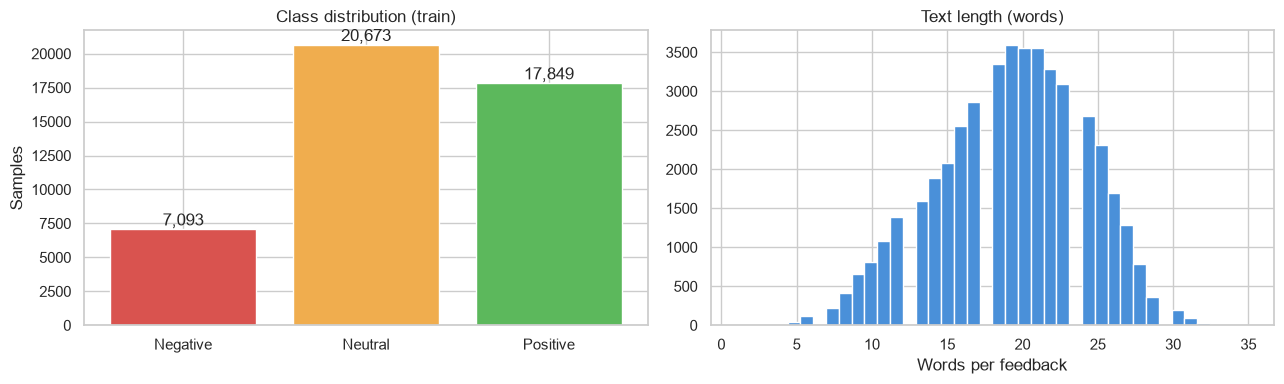

         count  mean  std  min   25%   50%   75%   max
label                                                 
0       7093.0  20.2  4.8  4.0  17.0  21.0  24.0  35.0
1      20673.0  19.0  4.9  1.0  16.0  19.0  23.0  33.0
2      17849.0  19.1  5.0  4.0  16.0  19.0  23.0  34.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class balance
counts = train_df['label'].value_counts().sort_index()
axes[0].bar(LABEL_NAMES, counts.values, color=['#d9534f', '#f0ad4e', '#5cb85c'])
axes[0].set_title('Class distribution (train)')
axes[0].set_ylabel('Samples')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# Text length
train_df['n_words'] = train_df['text'].str.split().str.len()
axes[1].hist(train_df['n_words'], bins=40, color='#4a90d9')
axes[1].set_title('Text length (words)')
axes[1].set_xlabel('Words per feedback')

plt.tight_layout()
plt.show()

print(train_df.groupby('label')['n_words'].describe().round(1))

**EDA takeaways** (fill in with your actual numbers after running):
- The dataset is moderately imbalanced — Neutral is the largest class. We report *macro F1*, not just accuracy, so every class counts equally.
- Texts are short (mostly under 40 words), so a max sequence length of 128 tokens is safe.
- No missing values; labels are already 0/1/2 integers matching Negative/Neutral/Positive.

## 3. NLP Preprocessing

For transformers, preprocessing is deliberately **light**: BERT-family tokenizers handle punctuation, casing and subwords themselves, and stripping too much (e.g. stopwords) *hurts* contextual models. We therefore only normalise noise that carries no sentiment signal: URLs and user mentions. We keep hashtag words and emoticons — they often carry the sentiment.

The heavier classical pipeline (lowercasing + TF-IDF tokenisation) is applied only to the baseline model.

In [5]:
def clean_text(text: str) -> str:
    text = re.sub(r'https?://\S+|www\.\S+', 'http', text)   # normalise URLs
    text = re.sub(r'@\w+', '@user', text)                     # anonymise mentions
    text = re.sub(r'\s+', ' ', text).strip()                  # collapse whitespace
    return text

for df in (train_df, val_df, test_df):
    df['clean_text'] = df['text'].apply(clean_text)

train_df[['text', 'clean_text']].sample(5, random_state=RANDOM_STATE)

,text,clean_text
11449,I forgot all about Ice Cube being in the movie...,I forgot all about Ice Cube being in the movie...
26433,playoffs are finally set. Chardon plays warren...,playoffs are finally set. Chardon plays warren...
33669,Are we just going to ignore the fact that Ice ...,Are we just going to ignore the fact that Ice ...
33013,If you live in the South Orlando area\u002c be...,If you live in the South Orlando area\u002c be...
13399,First record of Colin Baker at the BBC: BBC2 s...,First record of Colin Baker at the BBC: BBC2 s...


## 4. Baseline: TF-IDF + Logistic Regression

In [6]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                             lowercase=True, stop_words='english')
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test  = vectorizer.transform(test_df['clean_text'])

baseline = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
baseline.fit(X_train, train_df['label'])

baseline_preds = baseline.predict(X_test)
baseline_acc = accuracy_score(test_df['label'], baseline_preds)
baseline_f1  = f1_score(test_df['label'], baseline_preds, average='macro')

print(f'Baseline accuracy: {baseline_acc:.4f}   macro F1: {baseline_f1:.4f}\n')
print(classification_report(test_df['label'], baseline_preds, target_names=LABEL_NAMES))

Baseline accuracy: 0.5864   macro F1: 0.5541

              precision    recall  f1-score   support

    Negative       0.69      0.34      0.46      3972
     Neutral       0.59      0.75      0.66      5937
    Positive       0.51      0.59      0.55      2375

    accuracy                           0.59     12284
   macro avg       0.60      0.56      0.55     12284
weighted avg       0.60      0.59      0.57     12284



## 5. Transformer: fine-tune DistilBERT

DistilBERT keeps ~97% of BERT's language understanding at 40% fewer parameters — the right trade-off for a real-time inference API (core requirement 3).

In [7]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, DataCollatorWithPadding)
from datasets import Dataset

MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128

# On CPU, set this to e.g. 8000 to keep training time reasonable.
# On GPU/MPS, set to None to use the full training set.
TRAIN_SUBSET = 12000

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_dataset(df, subset=None):
    if subset is not None and len(df) > subset:
        df = df.sample(subset, random_state=RANDOM_STATE)
    ds = Dataset.from_pandas(df[['clean_text', 'label']].reset_index(drop=True))
    ds = ds.map(lambda b: tokenizer(b['clean_text'], truncation=True, max_length=MAX_LENGTH),
                batched=True, remove_columns=['clean_text'])
    return ds

train_ds = make_dataset(train_df, TRAIN_SUBSET)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print(train_ds)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 12000
})


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: 'Negative', 1: 'Neutral', 2: 'Positive'},
    label2id={'Negative': 0, 'Neutral': 1, 'Positive': 2},
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds),
            'macro_f1': f1_score(labels, preds, average='macro')}

args = TrainingArguments(
    output_dir='./checkpoints',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    report_to='none',
    seed=RANDOM_STATE,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


/Users/adityachitale/Desktop/LaunchED Global/Project/Sentiment Analysis Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
100,0.930182
200,0.776081
300,0.733903
400,0.738098
500,0.723571
600,0.683705
700,0.674958
800,0.634260
900,0.552803
1000,0.589207


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/adityachitale/Desktop/LaunchED Global/Project/Sentiment Analysis Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1500, training_loss=0.648040532430013, metrics={'train_runtime': 700.5865, 'train_samples_per_second': 34.257, 'train_steps_per_second': 2.141, 'total_flos': 282015702180000.0, 'train_loss': 0.648040532430013, 'epoch': 2.0})

In [9]:
val_metrics = trainer.evaluate(val_ds)
print('Validation:', {k: round(v, 4) for k, v in val_metrics.items() if k.startswith('eval_')})

/Users/adityachitale/Desktop/LaunchED Global/Project/Sentiment Analysis Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,Macro F1
0.526996,0.684150,1500,0.706500,0.685920


Validation: {'eval_loss': 0.6842, 'eval_accuracy': 0.7065, 'eval_macro_f1': 0.6859}


## 6. Evaluation on the held-out test set

/Users/adityachitale/Desktop/LaunchED Global/Project/Sentiment Analysis Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


DistilBERT accuracy: 0.6820   macro F1: 0.6797
Baseline   accuracy: 0.5864   macro F1: 0.5541

              precision    recall  f1-score   support

    Negative       0.71      0.67      0.69      3972
     Neutral       0.70      0.67      0.68      5937
    Positive       0.61      0.73      0.66      2375

    accuracy                           0.68     12284
   macro avg       0.67      0.69      0.68     12284
weighted avg       0.69      0.68      0.68     12284



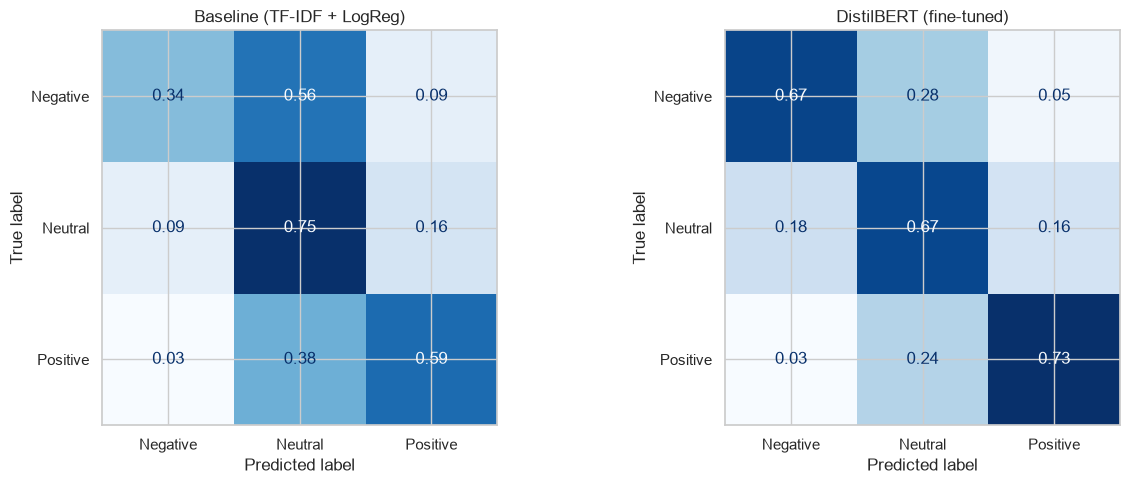

Saved metrics to ../6_Report/metrics.json


In [10]:
test_output = trainer.predict(test_ds)
bert_preds = np.argmax(test_output.predictions, axis=-1)
y_true = test_output.label_ids

bert_acc = accuracy_score(y_true, bert_preds)
bert_f1  = f1_score(y_true, bert_preds, average='macro')

print(f'DistilBERT accuracy: {bert_acc:.4f}   macro F1: {bert_f1:.4f}')
print(f'Baseline   accuracy: {baseline_acc:.4f}   macro F1: {baseline_f1:.4f}\n')
print(classification_report(y_true, bert_preds, target_names=LABEL_NAMES))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, yt, title in [
    (axes[0], baseline_preds, test_df['label'], 'Baseline (TF-IDF + LogReg)'),
    (axes[1], bert_preds, y_true, 'DistilBERT (fine-tuned)'),
]:
    cm = confusion_matrix(yt, preds, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES).plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=False)
    ax.set_title(title)
plt.tight_layout()

# Export figure + metrics for the analytical report (6_Report)
import json, os
os.makedirs('../6_Report/figures', exist_ok=True)
fig.savefig('../6_Report/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

metrics = {
    'baseline': {
        'accuracy': round(float(baseline_acc), 4), 'macro_f1': round(float(baseline_f1), 4),
        'per_class': classification_report(test_df['label'], baseline_preds,
                                           target_names=LABEL_NAMES, output_dict=True),
    },
    'distilbert': {
        'accuracy': round(float(bert_acc), 4), 'macro_f1': round(float(bert_f1), 4),
        'per_class': classification_report(y_true, bert_preds,
                                           target_names=LABEL_NAMES, output_dict=True),
    },
    'test_size': int(len(y_true)),
}
with open('../6_Report/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved metrics to ../6_Report/metrics.json')

### Error analysis

Looking at what the model gets wrong is where the report insights come from — typically Neutral↔Negative confusion on sarcastic or mixed-sentiment feedback.

In [11]:
test_texts = test_ds['clean_text'] if 'clean_text' in test_ds.column_names else test_df['clean_text'].tolist()
errors = pd.DataFrame({
    'text': test_df['clean_text'].reset_index(drop=True),
    'true': [LABEL_NAMES[i] for i in y_true],
    'predicted': [LABEL_NAMES[i] for i in bert_preds],
})
errors = errors[errors['true'] != errors['predicted']]
print(f'{len(errors):,} misclassified out of {len(y_true):,} ({len(errors)/len(y_true):.1%})\n')
errors.sample(10, random_state=RANDOM_STATE)

3,906 misclassified out of 12,284 (31.8%)



,text,true,predicted
5900,.@user @user - 30 year-old man who wants to le...,Neutral,Positive
8759,Agree w/ no death penalty. UR cafeteria Cathol...,Negative,Neutral
6100,A bird in the Pope Francis trend like actually...,Positive,Neutral
6575,@user social security card? Bank account? Just...,Neutral,Negative
4784,I want to like Maluma but he has only convince...,Neutral,Positive
9914,"Marlon: ""I’ll take away this shirt, get my tea...",Positive,Neutral
500,@user @user And it's why their first order of ...,Neutral,Negative
11474,Please RETWEET as much as u can! Americans for...,Positive,Neutral
954,I be mad Terry birthday in the same week as Ch...,Neutral,Negative
3150,The latest The Croatia Travel Daily! Thanks to...,Neutral,Positive


## 7. Save the model for the API

The FastAPI service (`3_API/`) automatically loads the model from `2_Model/distilbert-sentiment/` if it exists.

In [12]:
SAVE_DIR = '../2_Model/distilbert-sentiment'
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print('Model saved to', SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ../2_Model/distilbert-sentiment


## 8. Conclusions

Fill these in with your actual numbers for the report (`6_Report/`):

| Model | Accuracy | Macro F1 |
|---|---|---|
| TF-IDF + Logistic Regression | _from cell 4_ | _from cell 4_ |
| DistilBERT (fine-tuned) | _from cell 6_ | _from cell 6_ |

- The transformer's biggest gain is usually on the **Neutral** class, where bag-of-words models struggle because neutrality is about context, not keywords.
- Remaining errors concentrate in sarcasm and mixed-sentiment feedback ("great phone, terrible battery").
- The saved model powers the real-time API (`3_API/`), which writes every prediction to the database (`4_Database/`), which the dashboard (`5_Dashboard/`) visualises — completing all five core requirements.